In [10]:
# Calculations and plots for the given simple dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import isclose

In [11]:
# Data
x = np.array([1,2,3,4,5], dtype=float)
y = np.array([3,5,4,7,6], dtype=float)
n = len(x)

In [12]:
# Compute means
x_bar = x.mean()
y_bar = y.mean()

In [13]:
# OLS slope and intercept (closed form)
S_xy = np.sum((x - x_bar) * (y - y_bar))
S_xx = np.sum((x - x_bar)**2)
beta_hat = S_xy / S_xx
alpha_hat = y_bar - beta_hat * x_bar

In [14]:
# Predictions, residuals, SSR, SSE, SST, R^2
y_pred = alpha_hat + beta_hat * x
residuals = y - y_pred
SSR = np.sum((y_pred - y_bar)**2)   # regression sum of squares
SSE = np.sum(residuals**2)         # sum of squared errors (residual sum of squares)
SST = SSR + SSE                    # total sum of squares (also np.sum((y-y_bar)**2))
R_squared = SSR / SST if not isclose(SST, 0.0) else float('nan')

In [15]:
# Prepare DataFrame to show calculations
df = pd.DataFrame({
    'x': x,
    'y': y,
    'y_pred': np.round(y_pred, 4),
    'residual': np.round(residuals, 4),
    '(x-xbar)*(y-ybar)': np.round((x - x_bar)*(y - y_bar), 4),
    '(x-xbar)^2': np.round((x - x_bar)**2, 4)
})

In [16]:
display(df)

,x,y,y_pred,residual,(x-xbar)*(y-ybar),(x-xbar)^2
0,1.0,3.0,3.4,-0.4,4.0,4.0
1,2.0,5.0,4.2,0.8,-0.0,1.0
2,3.0,4.0,5.0,-1.0,-0.0,0.0
3,4.0,7.0,5.8,1.2,2.0,1.0
4,5.0,6.0,6.6,-0.6,2.0,4.0


In [17]:
print("Summary statistics and OLS estimates:")
print(f"n = {n}")
print(f"x_bar = {x_bar:.4f}, y_bar = {y_bar:.4f}")
print(f"S_xy = sum((x-xbar)*(y-ybar)) = {S_xy:.4f}")
print(f"S_xx = sum((x-xbar)^2) = {S_xx:.4f}")
print(f"Estimated slope (beta_hat) = {beta_hat:.6f}")
print(f"Estimated intercept (alpha_hat) = {alpha_hat:.6f}")
print()
print("Sums of squares:")
print(f"SSR (regression sum of squares) = {SSR:.6f}")
print(f"SSE (residual sum of squares) = {SSE:.6f}")
print(f"SST (total sum of squares) = {SST:.6f}")
print(f"R-squared = {R_squared:.6f}")

Summary statistics and OLS estimates:
n = 5
x_bar = 3.0000, y_bar = 5.0000
S_xy = sum((x-xbar)*(y-ybar)) = 8.0000
S_xx = sum((x-xbar)^2) = 10.0000
Estimated slope (beta_hat) = 0.800000
Estimated intercept (alpha_hat) = 2.600000

Sums of squares:
SSR (regression sum of squares) = 6.400000
SSE (residual sum of squares) = 3.600000
SST (total sum of squares) = 10.000000
R-squared = 0.640000


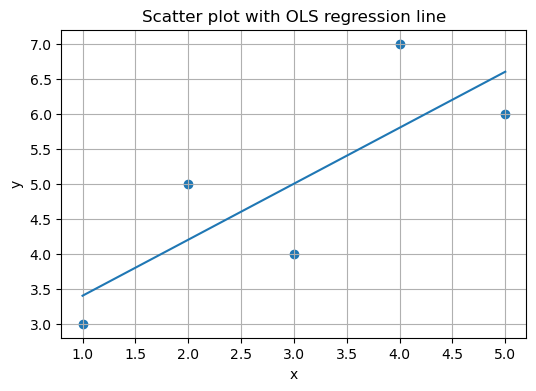

In [18]:
# Plot scatter and regression line
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, y_pred)  # default matplotlib colors
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot with OLS regression line')
plt.grid(True)
plt.show()